## Dataset 

In [2]:
from fedvaeexample.task import (
    Net,
    get_processed_data,
    #apply_eval_transforms,
    #get_weights,
    #set_weights,
    #test,
)

In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from datasets import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Custom batch collation function
def custom_collate(batch_list):
    """
    Custom collate function to handle datasets with both features and target column.
    
    Args:
        batch_list: List of items from the dataset
        
    Returns:
        Tuple of (features, labels) tensors
    """
    samples = []
    labels = []
    
    for item in batch_list:
        # Filter out the 'target' key and convert remaining items to features
        features = []
        
        for key, value in item.items():
            if key == 'target':
                labels.append(value)
            elif key.isdigit() or (isinstance(key, int)):
                # Handle numeric feature columns
                features.append(value)
        
        # If no target was found, use a default label
        if len(labels) < len(samples) + 1:
            labels.append(0)
            
        sample = torch.tensor(features, dtype=torch.float32)
        samples.append(sample)
    
    # Stack samples and labels into tensors
    features_tensor = torch.stack(samples)
    labels_tensor = torch.tensor(labels)
    
    return features_tensor, labels_tensor
    
def get_data(dataset_path, target_label=0):
    data = get_processed_data(dataset_path)
    
    data_shape = data.shape[1]
    print(f'data feature dim.: {data_shape}')
    
    # Create DataFrame with default index and column handling
    df = pd.DataFrame(data)
    
    # Add the same target label for all rows
    df['target'] = target_label
    
    # Convert to HuggingFace dataset
    dataset = Dataset.from_pandas(df)
    
    return dataset, data_shape

def combine_and_shuffle_datasets(dataset_paths, target_labels, feature_dim=None):
    """
    Combine multiple datasets with different feature dimensions and assign appropriate target labels.
    
    Args:
        dataset_paths (list): List of paths to datasets
        target_labels (list): List of target labels corresponding to each dataset
        feature_dim (int, optional): Target feature dimension for all datasets. If None, uses the max dimension.
    
    Returns:
        Combined and shuffled dataset with uniform feature dimension
    """
    if len(dataset_paths) != len(target_labels):
        raise ValueError("Number of dataset paths must match number of target labels")
    
    datasets = []
    dims = []
    
    # First pass: get each dataset and determine dimensions
    for path, label in zip(dataset_paths, target_labels):
        data = get_processed_data(path)
        dims.append(data.shape[1])
        
        # Create DataFrame
        df = pd.DataFrame(data)
        
        # Add the target label for all rows
        df['target'] = label
        
        datasets.append(df)
    
    # Determine target dimension
    if feature_dim is None:
        feature_dim = max(dims)
    
    # Second pass: pad or truncate features to match target dimension
    standardized_dfs = []
    for i, df in enumerate(datasets):
        current_dim = dims[i]
        
        if current_dim < feature_dim:
            # Pad with zeros to match target dimension
            for j in range(current_dim, feature_dim):
                df[j] = 0
        elif current_dim > feature_dim:
            # Truncate to match target dimension
            df = df.iloc[:, :feature_dim].copy()
            # Make sure to keep the target column
            df['target'] = datasets[i]['target']
        
        standardized_dfs.append(df)
    
    # Combine all datasets
    combined_df = pd.concat(standardized_dfs, ignore_index=True)
    
    # Shuffle the combined dataset
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Separate features and target
    features = combined_df.drop('target', axis=1)
    targets = combined_df['target']
    
    # Convert to HuggingFace dataset
    combined_dataset = Dataset.from_pandas(combined_df)
    
    return combined_dataset, feature_dim

In [5]:
# def test(net, testloader, device):
#     """Validate the VAE network on the entire test set and visualize worst reconstructions."""
#     total, loss = 0, 0.0
#     recon_total, kld_total = 0.0, 0.0
    
#     # Lists to store all images, reconstructions and their errors
#     all_features = []
#     all_reconstructions = []
#     all_recon_errors = []
    
#     with torch.no_grad():
#         for batch in testloader:
#             # Batch is already a tensor with shape [batch_size, num_features]
#             features = batch.to(device)
            
#             # Forward pass through the VAE
#             recon_features, mu, logvar = net(features)
            
#             # Compute losses
#             recon_loss = F.mse_loss(recon_features, features)
#             kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
#             batch_loss = recon_loss + 0.05 * kld_loss
            
#             # Track statistics
#             loss += batch_loss.item() * len(features)
#             recon_total += recon_loss.item() * len(features)
#             kld_total += kld_loss.item() * len(features)
#             total += len(features)
            
#             # Calculate per-sample reconstruction error
#             sample_recon_errors = torch.mean(torch.square(recon_features - features), dim=1)
            
#             # Store all samples
#             for i in range(len(features)):
#                 all_features.append(features[i].cpu())
#                 all_reconstructions.append(recon_features[i].cpu())
#                 all_recon_errors.append(sample_recon_errors[i].item())
    
#     # Convert lists to numpy arrays
#     all_recon_errors = np.array(all_recon_errors)
    
#     # Get the indices of the 10 worst reconstructed samples
#     worst10 = np.argsort(all_recon_errors)[-10:][::-1]
    
#     # Calculate average reconstruction error
#     avg_recon_error = np.mean(all_recon_errors)
#     print(f"Average reconstruction error: {avg_recon_error:.4f}")
    
#     avg_loss = loss / total
#     avg_recon = recon_total / total
#     avg_kld = kld_total / total
    
#     print(f"Test Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KLD: {avg_kld:.4f}")
    
    
#     plt.figure(figsize=(20, 4))
#     for i, idx in enumerate(worst10):
#         # Get the feature size
#         feature_size = all_features[idx].shape[0]
        
#         # For features with size 35, we can use 7x5 dimensions
#         if feature_size == 35:
#             height, width = 7, 5
#         else:
#             # Try to find reasonable dimensions - prefer width > height
#             factors = []
#             for j in range(1, int(np.sqrt(feature_size)) + 1):
#                 if feature_size % j == 0:
#                     factors.append((j, feature_size // j))
            
#             # Choose dimensions closest to a reasonable aspect ratio
#             if factors:
#                 factors.sort(key=lambda x: abs(x[1]/x[0] - 1.5))
#                 height, width = factors[0]
#             else:
#                 height, width = 1, feature_size
        
#         # Plot original image
#         plt.subplot(2, 10, i + 1)
#         plt.imshow(all_features[idx].reshape(height, width).numpy(), cmap='gray')
#         plt.title("Original")
#         plt.axis('off')
        
#         # Plot reconstructed image
#         plt.subplot(2, 10, i + 11)
#         plt.imshow(all_reconstructions[idx].reshape(height, width).numpy(), cmap='gray')
#         plt.title(f"RE {all_recon_errors[idx]:.3f}")
#         plt.axis('off')
    
#     plt.tight_layout()
#     #plt.savefig('vae_worst_reconstructions.png')
#     plt.show()
    
#     return avg_loss

In [6]:
def test(net, testloader, device):
    """Validate the VAE network on the entire test set and return a DataFrame with errors and true labels."""
    total, loss = 0, 0.0
    recon_total, kld_total = 0.0, 0.0
    
    # Lists to store all features, reconstructions, errors and labels
    all_features = []
    all_reconstructions = []
    all_recon_errors = []
    all_labels = []  # To store the true labels from the dataset
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(testloader):
            # Check if the batch contains labels (dataset with target attribute)
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                # If batch is (features, labels)
                features, labels = batch
                features = features.to(device)
                all_labels.extend(labels.cpu().numpy())
            else:
                # If batch is just features
                features = batch.to(device)
                # Use a default label if no labels are provided
                all_labels.extend([0] * len(features))
            
            # Forward pass through the VAE
            recon_features, mu, logvar = net(features)
            
            # Compute losses
            recon_loss = F.mse_loss(recon_features, features)
            kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            batch_loss = recon_loss + 0.05 * kld_loss
            
            # Track statistics
            loss += batch_loss.item() * len(features)
            recon_total += recon_loss.item() * len(features)
            kld_total += kld_loss.item() * len(features)
            total += len(features)
            
            # Calculate per-sample reconstruction error
            sample_recon_errors = torch.mean(torch.square(recon_features - features), dim=1)
            
            # Store all samples
            for i in range(len(features)):
                all_features.append(features[i].cpu())
                all_reconstructions.append(recon_features[i].cpu())
                all_recon_errors.append(sample_recon_errors[i].item())
    
    # Convert lists to numpy arrays
    all_recon_errors = np.array(all_recon_errors)
    
    # Get the indices of the 10 worst reconstructed samples
    worst10 = np.argsort(all_recon_errors)[-10:][::-1]
    
    # Calculate average reconstruction error
    avg_recon_error = np.mean(all_recon_errors)
    print(f"Average reconstruction error: {avg_recon_error:.4f}")
    
    avg_loss = loss / total
    avg_recon = recon_total / total
    avg_kld = kld_total / total
    
    print(f"Test Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KLD: {avg_kld:.4f}")
    
    # Visualization code
    plt.figure(figsize=(20, 4))
    for i, idx in enumerate(worst10):
        # Get the feature size
        feature_size = all_features[idx].shape[0]
        
        # For features with size 35, we can use 7x5 dimensions
        if feature_size == 35:
            height, width = 7, 5
        else:
            # Try to find reasonable dimensions - prefer width > height
            factors = []
            for j in range(1, int(np.sqrt(feature_size)) + 1):
                if feature_size % j == 0:
                    factors.append((j, feature_size // j))
            
            # Choose dimensions closest to a reasonable aspect ratio
            if factors:
                factors.sort(key=lambda x: abs(x[1]/x[0] - 1.5))
                height, width = factors[0]
            else:
                height, width = 1, feature_size
        
        # Plot original image
        plt.subplot(2, 10, i + 1)
        plt.imshow(all_features[idx].reshape(height, width).numpy(), cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Plot reconstructed image
        plt.subplot(2, 10, i + 11)
        plt.imshow(all_reconstructions[idx].reshape(height, width).numpy(), cmap='gray')
        plt.title(f"RE {all_recon_errors[idx]:.3f}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Create a DataFrame similar to your example
    recons_df = pd.DataFrame({
        'error': all_recon_errors,
        'y_true': all_labels
    }).reset_index(drop=True)
    
    return avg_loss, recons_df

dataset shape=(14962, 28)
Normalized row of data:
(14962, 35)


/usr/local/lib/python3.10/dist-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


dataset shape=(7122, 28)
Normalized row of data:
(7122, 42)


/usr/local/lib/python3.10/dist-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
/usr/local/lib/python3.10/dist-packages/datasets/table.py:719: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  return cls(pa.Table.from_pandas(*args, **kwargs))


Average reconstruction error: 0.1672
Test Loss: 0.1675, Recon: 0.1672, KLD: 0.0063


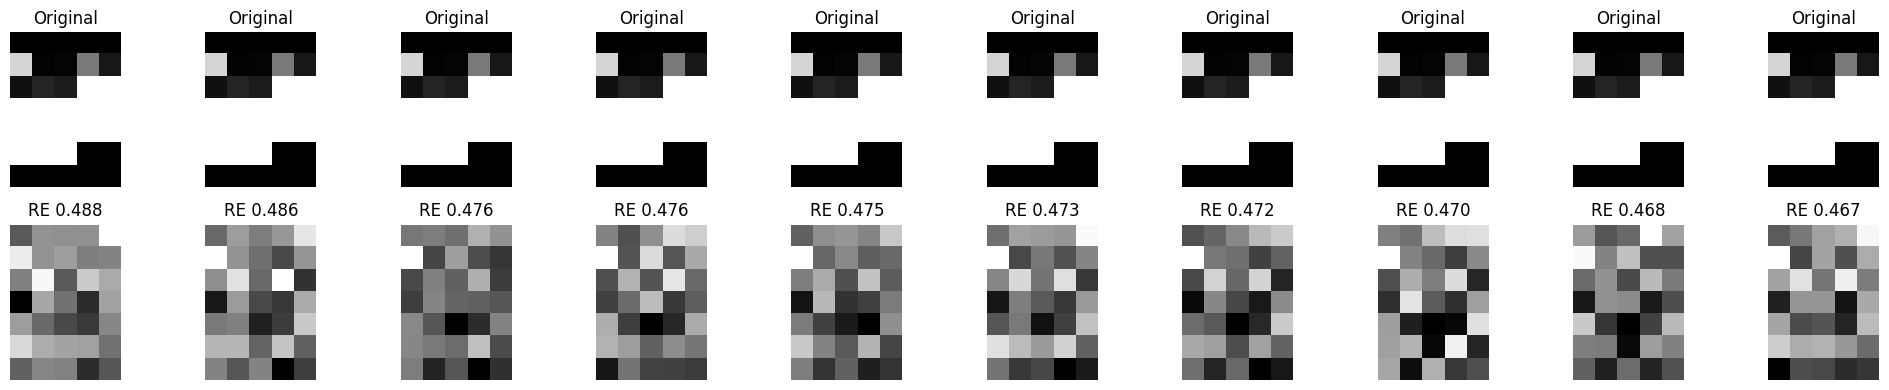

In [10]:
#test_dataset, test_dataset_shape = get_data("/workspace/datasets/desktop.tls/*.json", target_label=0) # 0 means benign     
dataset_paths = ["/workspace/datasets/desktop.tls/*.json", "/workspace/datasets/cic-aa.adware.tls/*.json"]
target_labels = [0, 1]  # Dataset1 has target 0, Dataset2 has target 1
#combined_dataset, data_shape = combine_and_shuffle_datasets(dataset_paths, target_labels)
combined_dataset, data_shape = combine_and_shuffle_datasets(dataset_paths, target_labels, feature_dim=35)
input_dim=data_shape
latent_dim=10
hidden_dim=64
device = "cpu"
testloader = DataLoader(
    #global_test_set.with_transform(apply_eval_transforms),
    combined_dataset,
    batch_size=1,
    collate_fn=custom_collate
)

autoencoder = Net(input_dim, latent_dim, hidden_dim)
avg_loss, recons_df = test(autoencoder, testloader, device)

In [8]:
recons_df.head()  # To view the first few rows of the DataFrame

,error,y_true
0,0.160069,1
1,0.139709,1
2,0.147217,1
3,0.186942,0
4,0.253473,0


/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


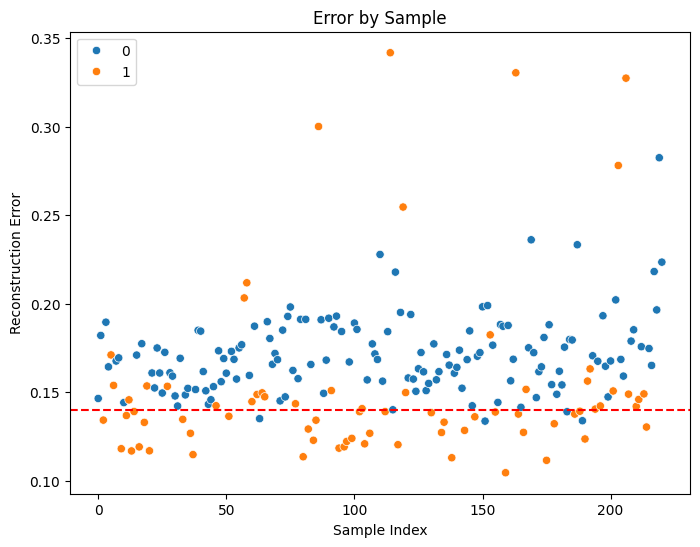

In [12]:
threshold = 0.14
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()